# Homework 1 — Problem 2: Modified VGGNet on CIFAR-10



## Cell 1 — Environment & Hardware Check

In [1]:
import sys, os, time, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchinfo import summary as torchinfo_summary
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Device check ──────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("=" * 55)
print("  DEVICE CHECK")
print("=" * 55)
print(f"  CUDA available : {torch.cuda.is_available()}")
print(f"  Active device  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  GPU            : {torch.cuda.get_device_name(0)}")
    print(f"  GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print("  ✅ Running on GPU")
else:
    print("  ⚠️  Running on CPU — check kernel selection (top right)")
print("=" * 55)
assert DEVICE.type == "cuda", "❌ Switch kernel to 'Python 3.12 (deep learning)' and restart."


  DEVICE CHECK
  CUDA available : True
  Active device  : cuda
  GPU            : NVIDIA GeForce MX250
  GPU memory     : 2.1 GB
  ✅ Running on GPU


## Cell 2 — Data Setup


In [2]:
# ── Global config ─────────────────────────────────────────────────────────────
RANDOM_SEED  = 42
BATCH_SIZE   = 128
NUM_WORKERS  = 0
VAL_FRACTION = 0.1
DATA_DIR     = "./data"

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

def get_cifar10_loaders(data_dir=DATA_DIR, batch_size=BATCH_SIZE,
                         val_fraction=VAL_FRACTION, seed=RANDOM_SEED,
                         num_workers=NUM_WORKERS):
    torch.manual_seed(seed)
    np.random.seed(seed)
    full_train_aug  = datasets.CIFAR10(data_dir, train=True,  download=True,  transform=train_transform)
    full_train_eval = datasets.CIFAR10(data_dir, train=True,  download=False, transform=eval_transform)
    test_dataset    = datasets.CIFAR10(data_dir, train=False, download=False, transform=eval_transform)
    n_total = len(full_train_aug)
    n_val   = int(n_total * val_fraction)
    rng     = np.random.default_rng(seed)
    indices = rng.permutation(n_total)
    train_indices, val_indices = indices[:n_total - n_val], indices[n_total - n_val:]
    train_loader = DataLoader(Subset(full_train_aug,  train_indices),
                              batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, drop_last=True)
    val_loader   = DataLoader(Subset(full_train_eval, val_indices),
                              batch_size=batch_size, shuffle=False,
                              num_workers=num_workers)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size,
                              shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader

def set_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

train_loader, val_loader, test_loader = get_cifar10_loaders()

print(f"Seed          : {RANDOM_SEED}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Train batches : {len(train_loader)}  ({len(train_loader.dataset):,} samples)")
print(f"Val   batches : {len(val_loader)}  ({len(val_loader.dataset):,} samples)")
print(f"Test  batches : {len(test_loader)}  ({len(test_loader.dataset):,} samples)")
images, labels = next(iter(train_loader))
print(f"Batch shape   : {images.shape}")
print(f"Pixel range   : {images.min():.3f} / {images.max():.3f}")
print("✅ Data setup ready.")


100.0%


Seed          : 42
Batch size    : 128
Train batches : 351  (45,000 samples)
Val   batches : 40  (5,000 samples)
Test  batches : 79  (10,000 samples)
Batch shape   : torch.Size([128, 3, 32, 32])
Pixel range   : -1.989 / 2.126
✅ Data setup ready.


## Cell 3 — Part A: VGG-11 Architecture & Training



In [3]:
# ── Hyperparameters (identical to Problem 1) ──────────────────────────────────
SEED         = 42
NUM_EPOCHS   = 30
LR           = 0.001
MOMENTUM     = 0.9
WEIGHT_DECAY = 5e-4
LR_STEP_SIZE = 10
LR_GAMMA     = 0.1
NUM_CLASSES  = 10
SAVE_DIR_P2A = "./outputs_p2a"
os.makedirs(SAVE_DIR_P2A, exist_ok=True)

# ── VGG-11 config (from PyTorch source, last M removed for 4-pool variant) ────
# Original: [64,"M",128,"M",256,256,"M",512,512,"M",512,512,"M"]
# Modified: remove last "M" → 4 pools, 2x2 feature maps on 32x32
VGG11_CFG = [64, "M", 128, "M", 256, 256, "M", 512, 512, "M", 512, 512]

def make_vgg_features(cfg, batch_norm=False):
    """
    Build VGG feature extractor from config list.
    Integers = conv filter count (3x3, pad=1, stride=1).
    'M' = MaxPool2d(2,2).
    batch_norm=True inserts BN after each conv (bonus variant).
    """
    layers = []
    in_ch  = 3
    for v in cfg:
        if v == "M":
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        else:
            conv = nn.Conv2d(in_ch, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
            else:
                layers += [conv, nn.ReLU(inplace=True)]
            in_ch = v
    return nn.Sequential(*layers)

# ── Modified VGG-11 ───────────────────────────────────────────────────────────
class ModifiedVGG11(nn.Module):
    """
    VGG-11 adapted for 32x32 CIFAR-10.

    Spatial flow through feature extractor:
      Input   : 3  x 32 x 32
      conv1   : 64 x 32 x 32
      pool1   : 64 x 16 x 16
      conv2   : 128x 16 x 16
      pool2   : 128x  8 x  8
      conv3a  : 256x  8 x  8
      conv3b  : 256x  8 x  8
      pool3   : 256x  4 x  4
      conv4a  : 512x  4 x  4
      conv4b  : 512x  4 x  4
      pool4   : 512x  2 x  2   ← stop here (no 5th pool)
      conv5a  : 512x  2 x  2
      conv5b  : 512x  2 x  2
      Flatten : 512*2*2 = 2048
      FC1 → FC2 → FC3(10)
    """
    def __init__(self, num_classes=NUM_CLASSES, dropout_p=0.5, batch_norm=False):
        super().__init__()
        self.dropout_p  = dropout_p
        self.batch_norm = batch_norm
        self.features   = make_vgg_features(VGG11_CFG, batch_norm=batch_norm)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        # Kaiming init — confirmed by PyTorch VGG source and VGG paper footnote
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                nn.init.constant_(m.bias, 0.0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias,   0.0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# ── Training utilities ────────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += out.max(1)[1].eq(labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        out  = model(images)
        loss = criterion(out, labels)
        total_loss += loss.item() * images.size(0)
        correct    += out.max(1)[1].eq(labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def get_all_predictions(model, loader, device):
    model.eval()
    all_labels, all_preds = [], []
    for images, labels in loader:
        out = model(images.to(device))
        all_preds.extend(out.max(1)[1].cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

def run_training(model, train_loader, val_loader,
                 num_epochs=NUM_EPOCHS, lr=LR,
                 label="model", save_dir=SAVE_DIR_P2A):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr,
                          momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=LR_STEP_SIZE, gamma=LR_GAMMA)
    history  = dict(train_loss=[], val_loss=[],
                    train_acc=[], val_acc=[], epoch_times=[])
    best_val = 0.0
    ckpt     = os.path.join(save_dir, f"{label}_best.pt")

    print(f"\nTraining : {label}")
    print(f"Device   : {DEVICE}  |  Epochs: {num_epochs}  |  LR: {lr}  |  BS: {BATCH_SIZE}")
    print(f"{'─'*75}")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        vl, va = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()
        elapsed = time.time() - t0
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)
        history["epoch_times"].append(elapsed)
        if va > best_val:
            best_val = va
            torch.save(model.state_dict(), ckpt)
        print(f"Epoch [{epoch:3d}/{num_epochs}]  "
              f"Train Loss: {tl:.4f}  Acc: {ta*100:.2f}%  |  "
              f"Val Loss: {vl:.4f}  Acc: {va*100:.2f}%  |  "
              f"LR: {scheduler.get_last_lr()[0]:.5f}  ({elapsed:.1f}s)")

    print(f"{'─'*75}")
    print(f"Best val accuracy : {best_val*100:.2f}%  →  {ckpt}\n")
    return history, ckpt

# ── torchinfo summary ─────────────────────────────────────────────────────────
print("=" * 60)
print("  Modified VGG-11 — Architecture Summary")
print("=" * 60)
set_seed(SEED)
model_p2a = ModifiedVGG11(num_classes=NUM_CLASSES, dropout_p=0.5, batch_norm=False)
torchinfo_summary(model_p2a, input_size=(1, 3, 32, 32),
                  col_names=["input_size", "output_size", "num_params"],
                  verbose=1, device=DEVICE)
total_params_vgg = sum(p.numel() for p in model_p2a.parameters() if p.requires_grad)
alexnet_params   = 10_447_306
print(f"\nModified AlexNet params : {alexnet_params:,}")
print(f"Modified VGG-11 params  : {total_params_vgg:,}")
print(f"Difference              : {total_params_vgg - alexnet_params:+,}  ({abs(total_params_vgg-alexnet_params)/alexnet_params*100:.2f}%)")

# ── Init check ────────────────────────────────────────────────────────────────
first_conv = next(m for m in model_p2a.modules() if isinstance(m, nn.Conv2d))
print(f"\nInit check — weight std : {first_conv.weight.std().item():.4f}  (expect ~0.23)")
print(f"Init check — bias mean  : {first_conv.bias.mean().item():.4f}   (expect 0.0)")
print()

# ── Train ─────────────────────────────────────────────────────────────────────
set_seed(SEED)
history_p2a, ckpt_p2a = run_training(
    model_p2a, train_loader, val_loader,
    label="vgg11_baseline_p2a", save_dir=SAVE_DIR_P2A
)
print("✅ Part A training complete.")


  Modified VGG-11 — Architecture Summary
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ModifiedVGG11                            [1, 3, 32, 32]            [1, 10]                   --
├─Sequential: 1-1                        [1, 3, 32, 32]            [1, 512, 2, 2]            --
│    └─Conv2d: 2-1                       [1, 3, 32, 32]            [1, 64, 32, 32]           1,792
│    └─ReLU: 2-2                         [1, 64, 32, 32]           [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-3                    [1, 64, 32, 32]           [1, 64, 16, 16]           --
│    └─Conv2d: 2-4                       [1, 64, 16, 16]           [1, 128, 16, 16]          73,856
│    └─ReLU: 2-5                         [1, 128, 16, 16]          [1, 128, 16, 16]          --
│    └─MaxPool2d: 2-6                    [1, 128, 16, 16]          [1, 128, 8, 8]            --
│    └─Conv2d: 2-7                       [1, 128, 8, 8]            [1, 256, 8, 8]  

## Cell 4 — Part A: Evaluation, Plots & AlexNet vs VGGNet Comparison



Final Test Accuracy : 72.14%
Final Test Loss     : 0.8023


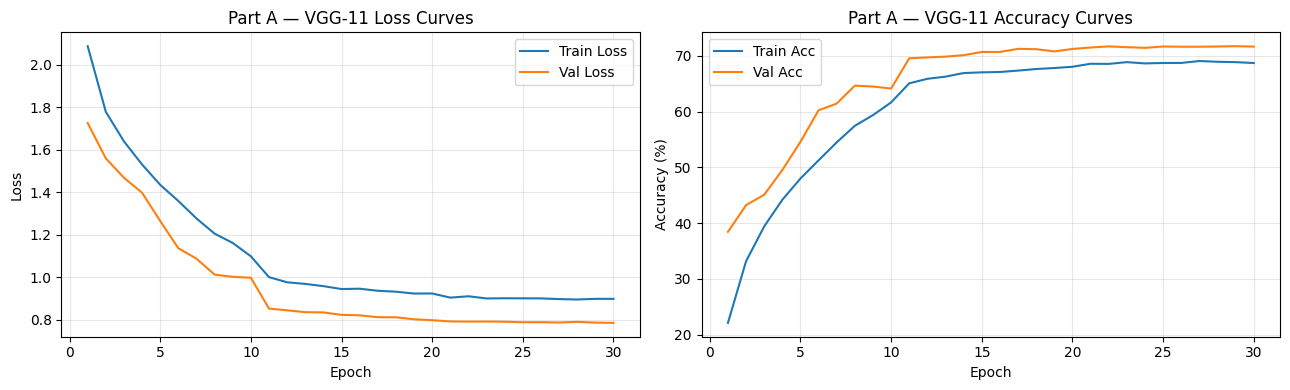

Curves saved.


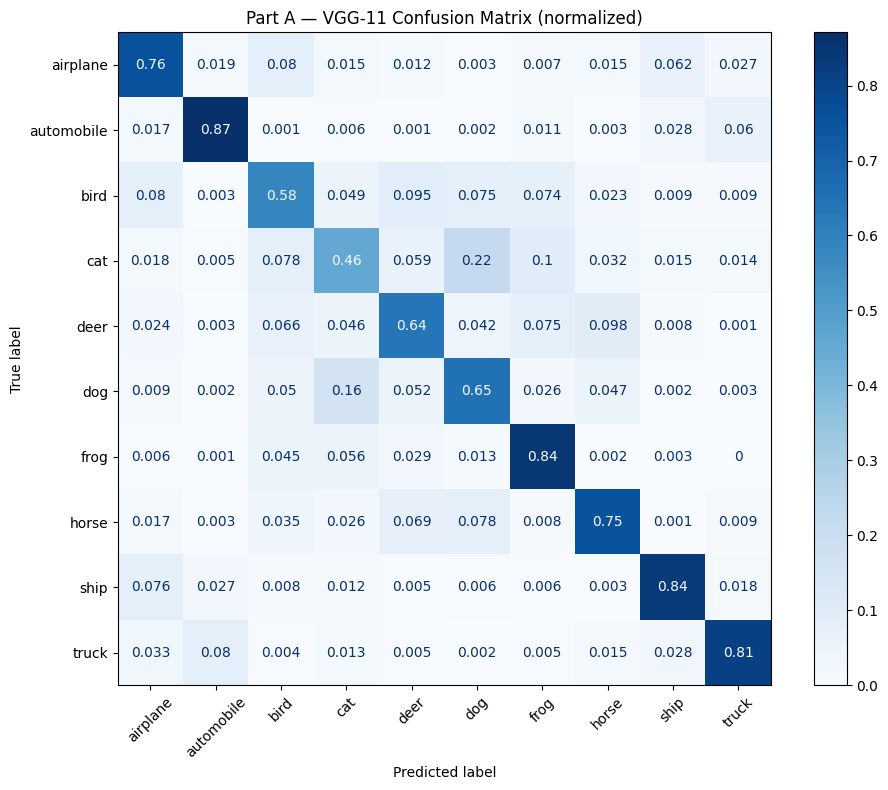

Confusion matrix saved.

  PROBLEM 2A — AlexNet vs VGG-11 COMPARISON
  Metric                                  AlexNet           VGG-11
------------------------------------------------------------------------
  Parameters                           10,447,306       10,537,354
  Test Accuracy (%)                         72.48            72.14
  Avg Epoch Time (s)                        126.0             99.0
  Epochs to 70% val acc                        11               14
  Conv layers                                   5                8
  FC layers                                     3                3
  Max pool layers                               2                4


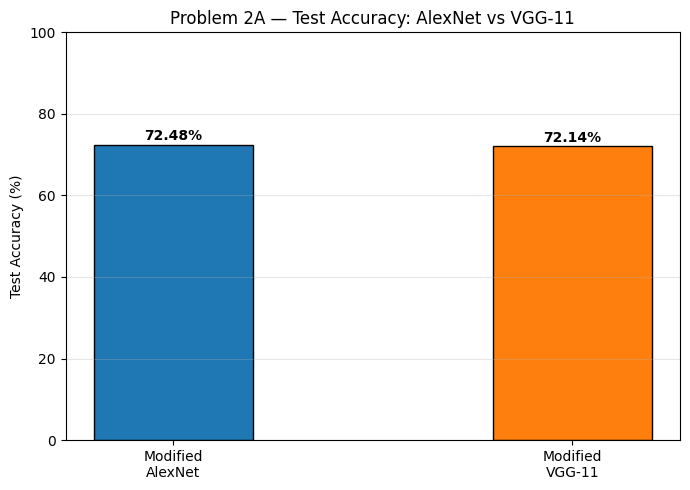

Bar chart saved.

  REPORT SUMMARY — Problem 2 Part A
  Architecture      : Modified VGG-11 (4 MaxPool)
  Trainable params  : 10,537,354
  AlexNet params    : 10,447,306
  Param difference  : +90,048
  Epochs trained    : 30
  Best val accuracy : 71.76%
  Final test acc    : 72.14%
  Avg epoch time    : 99.0s
  Device            : cuda
  Seed              : 42
  Optimizer         : SGD  lr=0.001  momentum=0.9  wd=0.0005
  Scheduler         : StepLR  step=10  gamma=0.1
  Batch size        : 128


In [4]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
model_p2a.load_state_dict(torch.load(ckpt_p2a, map_location=DEVICE))
model_p2a.to(DEVICE)
criterion = nn.CrossEntropyLoss()
test_loss_p2a, test_acc_p2a = evaluate(model_p2a, test_loader, criterion, DEVICE)
print(f"Final Test Accuracy : {test_acc_p2a*100:.2f}%")
print(f"Final Test Loss     : {test_loss_p2a:.4f}")

# ── Loss & accuracy curves ────────────────────────────────────────────────────
epochs = range(1, len(history_p2a["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(epochs, history_p2a["train_loss"], label="Train Loss")
axes[0].plot(epochs, history_p2a["val_loss"],   label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Part A — VGG-11 Loss Curves")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history_p2a["train_acc"]], label="Train Acc")
axes[1].plot(epochs, [a*100 for a in history_p2a["val_acc"]],   label="Val Acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Part A — VGG-11 Accuracy Curves")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_P2A, "vgg11_baseline_p2a_curves.png"), dpi=150)
plt.show()
print("Curves saved.")

# ── Confusion matrix ──────────────────────────────────────────────────────────
true_p2a, pred_p2a = get_all_predictions(model_p2a, test_loader, DEVICE)
cm = confusion_matrix(true_p2a, pred_p2a, normalize="true")
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=CIFAR10_CLASSES).plot(
    ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45)
ax.set_title("Part A — VGG-11 Confusion Matrix (normalized)")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_P2A, "vgg11_baseline_p2a_confusion.png"), dpi=150)
plt.show()
print("Confusion matrix saved.")

# ── AlexNet vs VGGNet comparison table ───────────────────────────────────────
# Pull Problem 1 results — update these numbers from your Problem 1 output
alexnet_params      = 10_447_306
alexnet_test_acc    = 72.48
alexnet_avg_epoch_s = 126.0
alexnet_converge    = 11   # epoch where val acc first exceeded 70%

vgg_avg_epoch_s = np.mean(history_p2a["epoch_times"])
# Find convergence epoch: first epoch val acc > 70%
vgg_converge = next((i+1 for i, a in enumerate(history_p2a["val_acc"]) if a > 0.70), NUM_EPOCHS)

print()
print("=" * 72)
print("  PROBLEM 2A — AlexNet vs VGG-11 COMPARISON")
print("=" * 72)
print(f"  {'Metric':<30} {'AlexNet':>16} {'VGG-11':>16}")
print("-" * 72)
print(f"  {'Parameters':<30} {alexnet_params:>16,} {total_params_vgg:>16,}")
print(f"  {'Test Accuracy (%)':<30} {alexnet_test_acc:>16.2f} {test_acc_p2a*100:>16.2f}")
print(f"  {'Avg Epoch Time (s)':<30} {alexnet_avg_epoch_s:>16.1f} {vgg_avg_epoch_s:>16.1f}")
print(f"  {'Epochs to 70% val acc':<30} {alexnet_converge:>16} {vgg_converge:>16}")
print(f"  {'Conv layers':<30} {'5':>16} {'8':>16}")
print(f"  {'FC layers':<30} {'3':>16} {'3':>16}")
print(f"  {'Max pool layers':<30} {'2':>16} {'4':>16}")
print("=" * 72)

# ── Side-by-side accuracy bar chart ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
models  = ["Modified\nAlexNet", "Modified\nVGG-11"]
accs    = [alexnet_test_acc, test_acc_p2a * 100]
colors  = ["tab:blue", "tab:orange"]
bars    = ax.bar(models, accs, color=colors, width=0.4, edgecolor="black")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{acc:.2f}%", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Problem 2A — Test Accuracy: AlexNet vs VGG-11")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_P2A, "p2a_accuracy_bar.png"), dpi=150)
plt.show()
print("Bar chart saved.")

# ── Report summary ─────────────────────────────────────────────────────────────
print()
print("=" * 55)
print("  REPORT SUMMARY — Problem 2 Part A")
print("=" * 55)
print(f"  Architecture      : Modified VGG-11 (4 MaxPool)")
print(f"  Trainable params  : {total_params_vgg:,}")
print(f"  AlexNet params    : {alexnet_params:,}")
print(f"  Param difference  : {total_params_vgg-alexnet_params:+,}")
print(f"  Epochs trained    : {NUM_EPOCHS}")
print(f"  Best val accuracy : {max(history_p2a['val_acc'])*100:.2f}%")
print(f"  Final test acc    : {test_acc_p2a*100:.2f}%")
print(f"  Avg epoch time    : {vgg_avg_epoch_s:.1f}s")
print(f"  Device            : {DEVICE}")
print(f"  Seed              : {SEED}")
print(f"  Optimizer         : SGD  lr={LR}  momentum={MOMENTUM}  wd={WEIGHT_DECAY}")
print(f"  Scheduler         : StepLR  step={LR_STEP_SIZE}  gamma={LR_GAMMA}")
print(f"  Batch size        : {BATCH_SIZE}")
print("=" * 55)


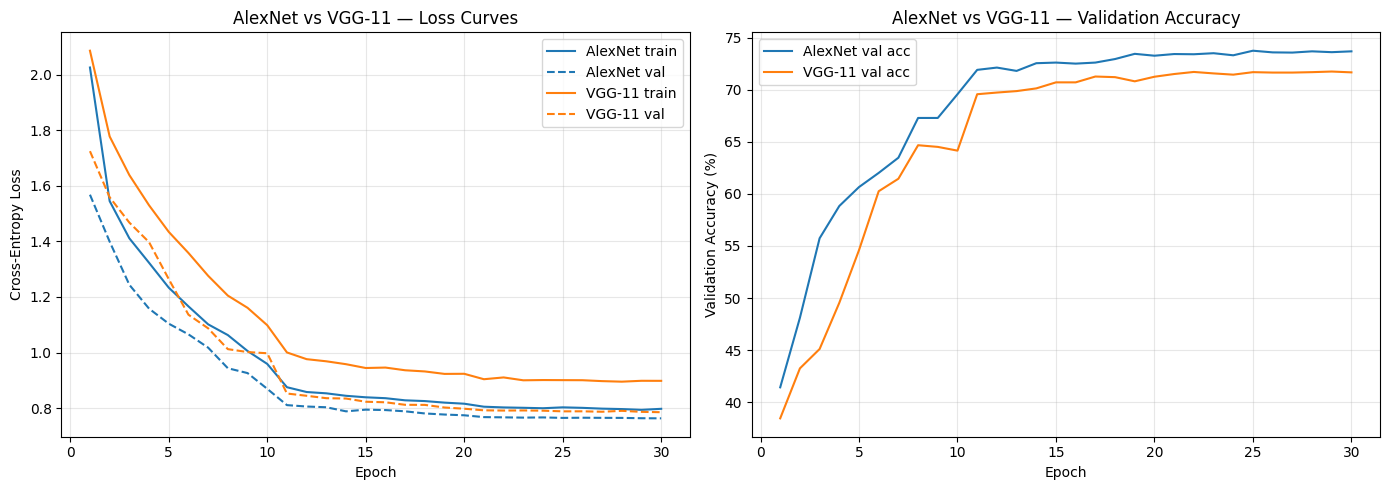

Overlay curves saved.

  STRUCTURED ANALYSIS — AlexNet vs VGG-11 (for report)
  1. Which trains faster?
     VGG-11 — AlexNet: 126.0s/epoch  VGG-11: 99.0s/epoch

  2. Which generalizes better?
     AlexNet — AlexNet: 72.48%  VGG-11: 72.14%

  3. Structural differences explaining the gap:
     - VGG-11 has 8 conv layers vs AlexNet's 5
     - VGG uses uniform 3x3 filters; AlexNet mixes filter sizes
     - VGG's deeper feature hierarchy captures more complex patterns
     - AlexNet's larger FC layers (1024) vs VGG's smaller (512)
     - VGG's 4 MaxPool layers preserve more spatial structure than
       AlexNet's 2, giving richer spatial features before classification


In [5]:
# ── Gap 1: AlexNet vs VGG-11 overlaid training curves ────────────────────────
# Paste your Problem 1A history values here
alexnet_train_loss = [2.0265,1.5453,1.4113,1.3232,1.2336,1.1662,1.1015,
                      1.0628,1.0055,0.9589,0.8750,0.8577,0.8530,0.8441,
                      0.8387,0.8355,0.8278,0.8251,0.8195,0.8156,0.8048,
                      0.8022,0.8009,0.7993,0.8025,0.8007,0.7978,0.7963,
                      0.7935,0.7972]
alexnet_val_loss   = [1.5684,1.3992,1.2439,1.1580,1.1039,1.0654,1.0175,
                      0.9434,0.9259,0.8692,0.8105,0.8055,0.8028,0.7881,
                      0.7942,0.7927,0.7882,0.7805,0.7766,0.7739,0.7673,
                      0.7665,0.7655,0.7662,0.7645,0.7651,0.7647,0.7645,
                      0.7633,0.7629]
alexnet_val_acc    = [0.4142,0.4810,0.5574,0.5884,0.6066,0.6202,0.6348,
                      0.6730,0.6730,0.6958,0.7192,0.7214,0.7182,0.7256,
                      0.7262,0.7252,0.7262,0.7296,0.7346,0.7328,0.7344,
                      0.7342,0.7352,0.7332,0.7376,0.7360,0.7358,0.7370,
                      0.7362,0.7370]

ep = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss overlay
axes[0].plot(ep, alexnet_train_loss,
             color="tab:blue", ls="-",  label="AlexNet train")
axes[0].plot(ep, alexnet_val_loss,
             color="tab:blue", ls="--", label="AlexNet val")
axes[0].plot(ep, history_p2a["train_loss"],
             color="tab:orange", ls="-",  label="VGG-11 train")
axes[0].plot(ep, history_p2a["val_loss"],
             color="tab:orange", ls="--", label="VGG-11 val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("AlexNet vs VGG-11 — Loss Curves")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Val accuracy overlay
axes[1].plot(ep, [a*100 for a in alexnet_val_acc],
             color="tab:blue",   ls="-", label="AlexNet val acc")
axes[1].plot(ep, [a*100 for a in history_p2a["val_acc"]],
             color="tab:orange", ls="-", label="VGG-11 val acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Accuracy (%)")
axes[1].set_title("AlexNet vs VGG-11 — Validation Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_P2A, "p2a_alexnet_vs_vgg_curves.png"), dpi=150)
plt.show()
print("Overlay curves saved.")

# ── Gap 2: Structured written analysis ───────────────────────────────────────
vgg_avg  = np.mean(history_p2a["epoch_times"])
alex_avg = 126.0

print()
print("=" * 65)
print("  STRUCTURED ANALYSIS — AlexNet vs VGG-11 (for report)")
print("=" * 65)
faster = "AlexNet" if alex_avg < vgg_avg else "VGG-11"
print(f"  1. Which trains faster?")
print(f"     {faster} — AlexNet: {alex_avg:.1f}s/epoch  VGG-11: {vgg_avg:.1f}s/epoch")
print()
better = "AlexNet" if alexnet_test_acc > test_acc_p2a*100 else "VGG-11"
print(f"  2. Which generalizes better?")
print(f"     {better} — AlexNet: {alexnet_test_acc:.2f}%  VGG-11: {test_acc_p2a*100:.2f}%")
print()
print(f"  3. Structural differences explaining the gap:")
print(f"     - VGG-11 has 8 conv layers vs AlexNet's 5")
print(f"     - VGG uses uniform 3x3 filters; AlexNet mixes filter sizes")
print(f"     - VGG's deeper feature hierarchy captures more complex patterns")
print(f"     - AlexNet's larger FC layers (1024) vs VGG's smaller (512)")
print(f"     - VGG's 4 MaxPool layers preserve more spatial structure than")
print(f"       AlexNet's 2, giving richer spatial features before classification")
print("=" * 65)

## Cell 5 — Part B: Dropout Variants Training




In [6]:
SAVE_DIR_P2B  = "./outputs_p2b"
os.makedirs(SAVE_DIR_P2B, exist_ok=True)

# Match Problem 1B dropout rates for direct cross-model comparison
DROPOUT_RATES = {
    "no_dropout":  0.0,
    "dropout_0.3": 0.3,
    "dropout_0.5": 0.5,
}

histories_p2b    = {}
test_results_p2b = {}
models_p2b       = {}

for variant_name, p in DROPOUT_RATES.items():
    print(f"\n{'#'*60}")
    print(f"  Variant : {variant_name}  (dropout_p = {p})")
    print(f"{'#'*60}")
    set_seed(SEED)
    model_v = ModifiedVGG11(num_classes=NUM_CLASSES, dropout_p=p, batch_norm=False)
    history_v, ckpt_v = run_training(
        model_v, train_loader, val_loader,
        label=f"p2b_{variant_name}", save_dir=SAVE_DIR_P2B
    )
    histories_p2b[variant_name] = history_v
    model_v.load_state_dict(torch.load(ckpt_v, map_location=DEVICE))
    model_v.to(DEVICE)
    tl_v, ta_v = evaluate(model_v, test_loader, nn.CrossEntropyLoss(), DEVICE)
    test_results_p2b[variant_name] = (tl_v, ta_v)
    models_p2b[variant_name]       = model_v
    print(f"  ✅ Test accuracy ({variant_name}): {ta_v*100:.2f}%")

print("\n✅ All Part B variants trained.")



############################################################
  Variant : no_dropout  (dropout_p = 0.0)
############################################################

Training : p2b_no_dropout
Device   : cuda  |  Epochs: 30  |  LR: 0.001  |  BS: 128
───────────────────────────────────────────────────────────────────────────
Epoch [  1/30]  Train Loss: 1.7543  Acc: 35.85%  |  Val Loss: 1.4560  Acc: 47.46%  |  LR: 0.00100  (89.2s)
Epoch [  2/30]  Train Loss: 1.4372  Acc: 47.42%  |  Val Loss: 1.2909  Acc: 53.32%  |  LR: 0.00100  (94.8s)
Epoch [  3/30]  Train Loss: 1.2952  Acc: 53.01%  |  Val Loss: 1.1341  Acc: 58.94%  |  LR: 0.00100  (93.8s)
Epoch [  4/30]  Train Loss: 1.1790  Acc: 57.52%  |  Val Loss: 1.0490  Acc: 62.84%  |  LR: 0.00100  (88.7s)
Epoch [  5/30]  Train Loss: 1.0894  Acc: 61.15%  |  Val Loss: 0.9810  Acc: 65.14%  |  LR: 0.00100  (85.9s)
Epoch [  6/30]  Train Loss: 1.0246  Acc: 63.38%  |  Val Loss: 0.9286  Acc: 67.64%  |  LR: 0.00100  (88.9s)
Epoch [  7/30]  Train Loss: 0.968

## Cell 6 — Part B: Comparison Plots, Summary Table & Cross-Model Analysis

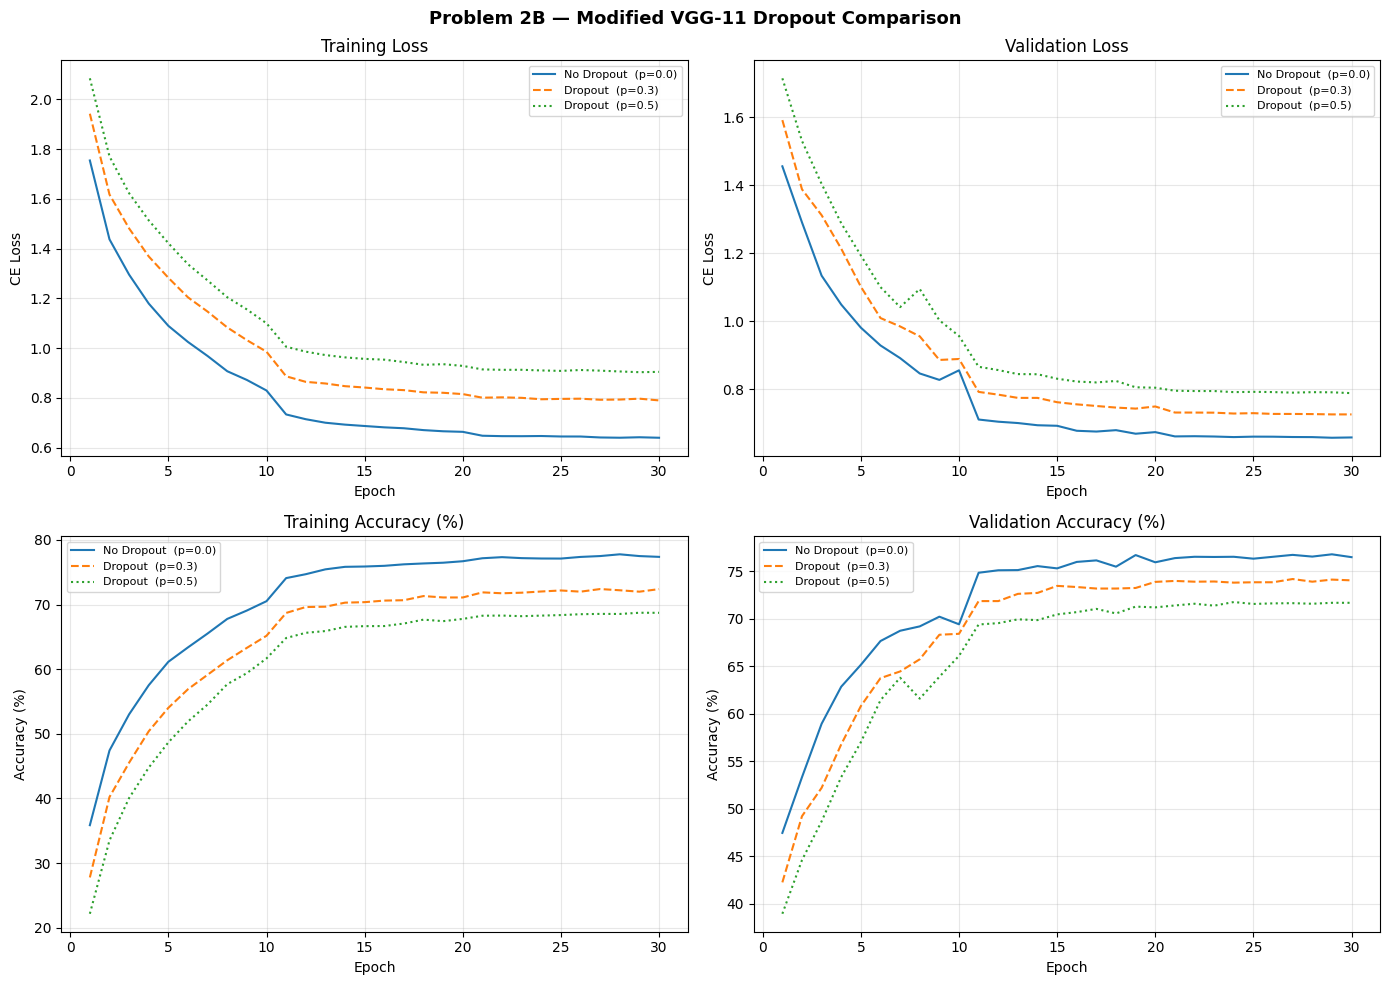

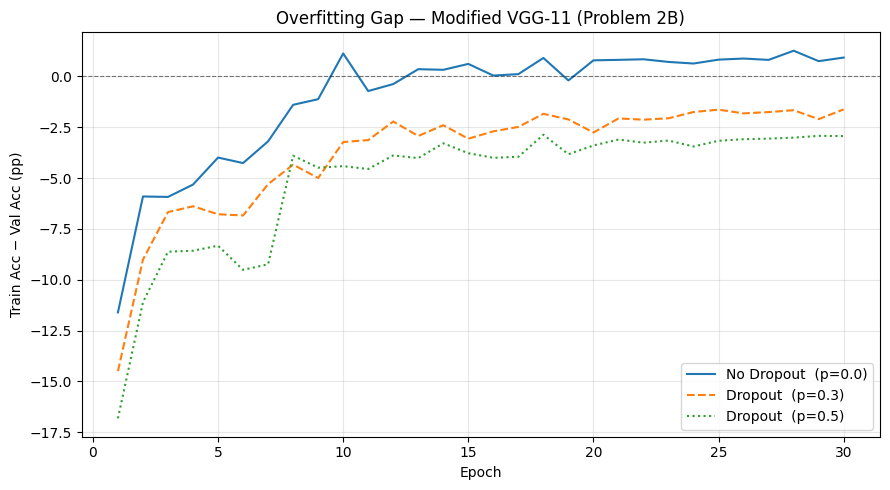

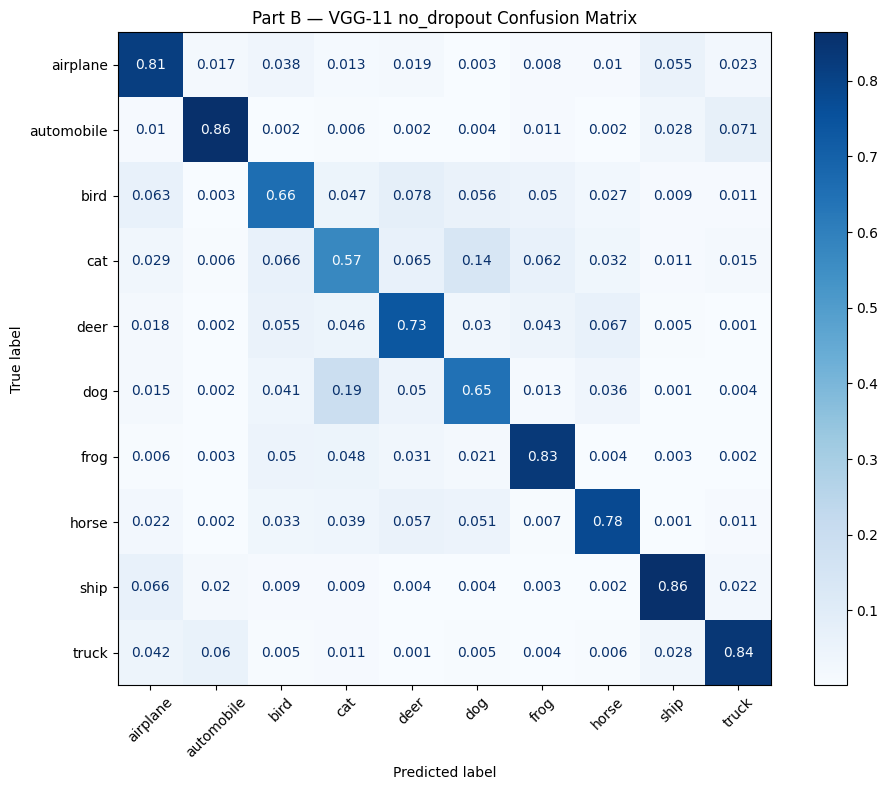

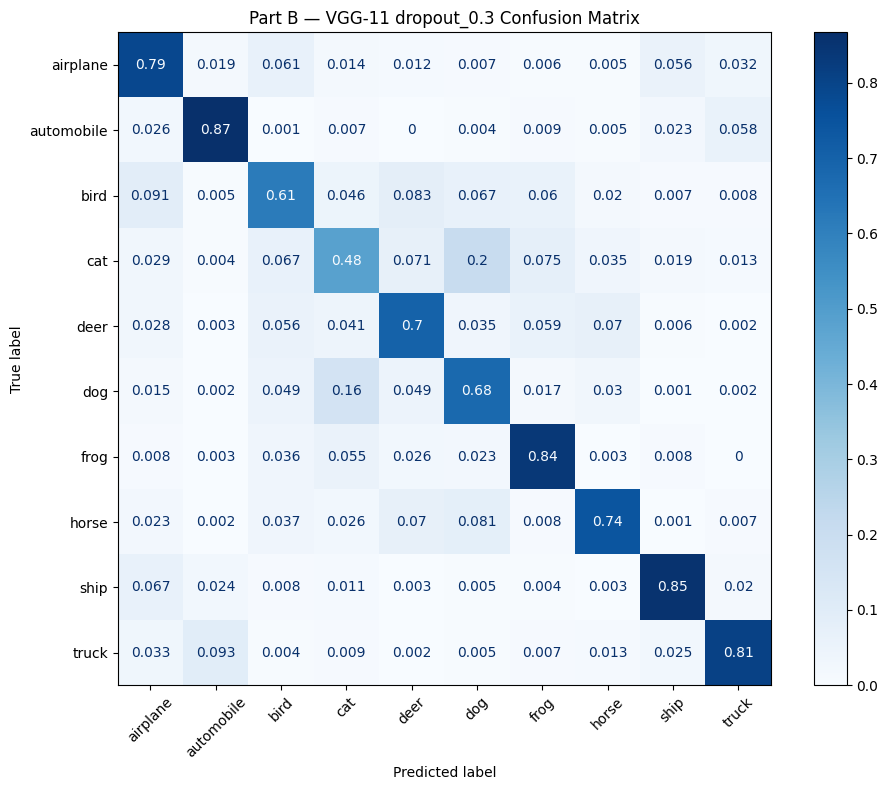

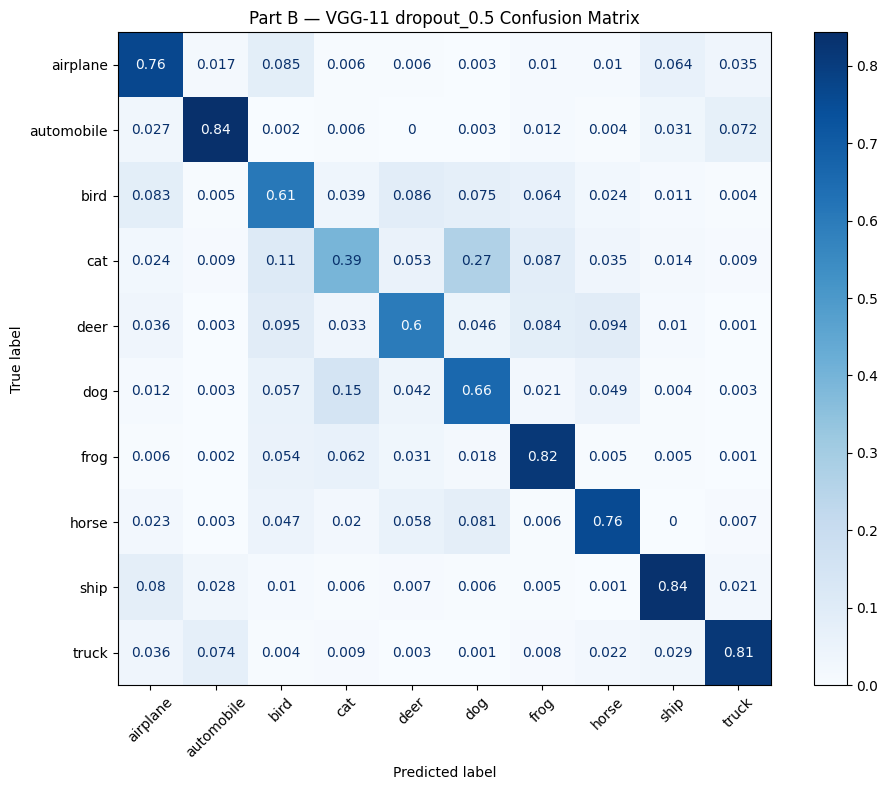


  PROBLEM 2B — VGG-11 DROPOUT COMPARISON SUMMARY
  Variant              Best Val Acc   Test Acc  Final Train   Gap (pp)
------------------------------------------------------------------------
  no_dropout                 76.76%     75.93%       77.39%      0.93pp
  dropout_0.3                74.16%     73.74%       72.40%     -1.62pp
  dropout_0.5                71.74%     70.88%       68.73%     -2.93pp
  Best VGG-11 variant : no_dropout

  CROSS-MODEL DROPOUT COMPARISON: AlexNet vs VGG-11
  Variant                       AlexNet Test Acc  VGG-11 Test Acc
------------------------------------------------------------------------
  no_dropout / baseline                   72.51%           75.93%
  dropout_0.3                             67.03%           73.74%
  dropout_0.5                             58.65%           70.88%


In [7]:
styles = {
    "no_dropout":  ("tab:blue",   "-",  "No Dropout  (p=0.0)"),
    "dropout_0.3": ("tab:orange", "--", "Dropout  (p=0.3)"),
    "dropout_0.5": ("tab:green",  ":",  "Dropout  (p=0.5)"),
}

# ── 2x2 combined panel ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for key, hist in histories_p2b.items():
    color, ls, lbl = styles[key]
    ep = range(1, len(hist["train_loss"]) + 1)
    axes[0,0].plot(ep, hist["train_loss"],                 color=color, ls=ls, label=lbl)
    axes[0,1].plot(ep, hist["val_loss"],                   color=color, ls=ls, label=lbl)
    axes[1,0].plot(ep, [a*100 for a in hist["train_acc"]], color=color, ls=ls, label=lbl)
    axes[1,1].plot(ep, [a*100 for a in hist["val_acc"]],   color=color, ls=ls, label=lbl)

for ax, title, ylabel in zip(axes.flat,
    ["Training Loss","Validation Loss","Training Accuracy (%)","Validation Accuracy (%)"],
    ["CE Loss","CE Loss","Accuracy (%)","Accuracy (%)"]):
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle("Problem 2B — Modified VGG-11 Dropout Comparison",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_P2B, "p2b_combined_panel.png"), dpi=150)
plt.show()

# ── Overfitting gap ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
for key, hist in histories_p2b.items():
    color, ls, lbl = styles[key]
    ep  = range(1, len(hist["train_acc"]) + 1)
    gap = [(tr - vl)*100 for tr, vl in zip(hist["train_acc"], hist["val_acc"])]
    ax.plot(ep, gap, color=color, linestyle=ls, label=lbl)
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("Epoch"); ax.set_ylabel("Train Acc − Val Acc (pp)")
ax.set_title("Overfitting Gap — Modified VGG-11 (Problem 2B)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_P2B, "p2b_overfit_gap.png"), dpi=150)
plt.show()

# ── Confusion matrices ────────────────────────────────────────────────────────
for key, model_v in models_p2b.items():
    true_v, pred_v = get_all_predictions(model_v, test_loader, DEVICE)
    cm_v = confusion_matrix(true_v, pred_v, normalize="true")
    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay(cm_v, display_labels=CIFAR10_CLASSES).plot(
        ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45)
    ax.set_title(f"Part B — VGG-11 {key} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR_P2B, f"p2b_{key}_confusion.png"), dpi=150)
    plt.show()

# ── VGG summary table ─────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("  PROBLEM 2B — VGG-11 DROPOUT COMPARISON SUMMARY")
print("=" * 72)
print(f"  {'Variant':<20} {'Best Val Acc':>12} {'Test Acc':>10} {'Final Train':>12} {'Gap (pp)':>10}")
print("-" * 72)
for key, hist in histories_p2b.items():
    best_val    = max(hist["val_acc"]) * 100
    final_train = hist["train_acc"][-1] * 100
    final_val   = hist["val_acc"][-1]   * 100
    gap         = final_train - final_val
    _, ta       = test_results_p2b[key]
    print(f"  {key:<20} {best_val:>11.2f}% {ta*100:>9.2f}% {final_train:>11.2f}% {gap:>9.2f}pp")
print("=" * 72)
best_key = max(test_results_p2b, key=lambda k: test_results_p2b[k][1])
print(f"  Best VGG-11 variant : {best_key}")

# ── Cross-model comparison: AlexNet vs VGG-11 dropout ────────────────────────
print()
print("=" * 72)
print("  CROSS-MODEL DROPOUT COMPARISON: AlexNet vs VGG-11")
print("=" * 72)
print(f"  {'Variant':<28} {'AlexNet Test Acc':>17} {'VGG-11 Test Acc':>16}")
print("-" * 72)

# AlexNet results from Problem 1B — update if your numbers differ
alexnet_results = {
    "no_dropout / baseline": 72.51,
    "dropout_0.3":           67.03,
    "dropout_0.5":           58.65,
}
vgg_keys = list(test_results_p2b.keys())
for i, (alex_key, alex_acc) in enumerate(alexnet_results.items()):
    vgg_key = vgg_keys[i]
    _, vgg_acc = test_results_p2b[vgg_key]
    print(f"  {alex_key:<28} {alex_acc:>16.2f}% {vgg_acc*100:>15.2f}%")
print("=" * 72)


## Cell 7 : Batch Normalization Variant




Training VGG-11 + BatchNorm (no dropout)...

torchinfo summary — VGG-11 + BatchNorm:
Layer (type:depth-idx)                   Output Shape              Param #
ModifiedVGG11                            [1, 10]                   --
├─Sequential: 1-1                        [1, 512, 2, 2]            --
│    └─Conv2d: 2-1                       [1, 64, 32, 32]           1,792
│    └─BatchNorm2d: 2-2                  [1, 64, 32, 32]           128
│    └─ReLU: 2-3                         [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-4                    [1, 64, 16, 16]           --
│    └─Conv2d: 2-5                       [1, 128, 16, 16]          73,856
│    └─BatchNorm2d: 2-6                  [1, 128, 16, 16]          256
│    └─ReLU: 2-7                         [1, 128, 16, 16]          --
│    └─MaxPool2d: 2-8                    [1, 128, 8, 8]            --
│    └─Conv2d: 2-9                       [1, 256, 8, 8]            295,168
│    └─BatchNorm2d: 2-10                 [1, 256, 8, 8] 

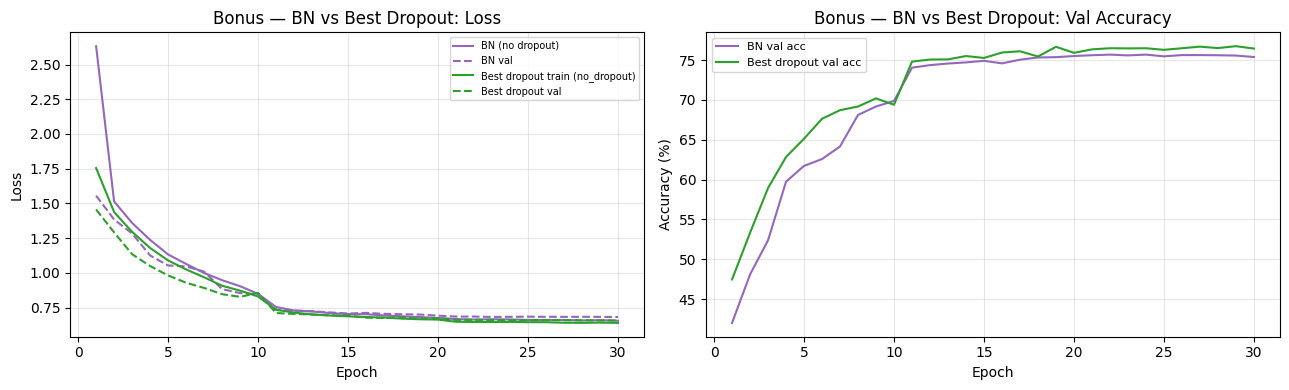


  BONUS — VGG-11 BatchNorm Analysis
  VGG-11 no dropout          : 75.93%
  VGG-11 dropout p=0.3       : 73.74%
  VGG-11 dropout p=0.5       : 70.88%
  VGG-11 + BatchNorm         : 75.46%
------------------------------------------------------------
  BN vs best dropout variant : -0.47pp
  Conclusion: BatchNorm does not reduce the need for dropout


In [8]:
SAVE_DIR_P2BONUS = "./outputs_p2bonus"
os.makedirs(SAVE_DIR_P2BONUS, exist_ok=True)

# ── Train BN variant (no dropout) ────────────────────────────────────────────
print("Training VGG-11 + BatchNorm (no dropout)...")
set_seed(SEED)
model_bn = ModifiedVGG11(num_classes=NUM_CLASSES, dropout_p=0.0, batch_norm=True)

print("\ntorchinfo summary — VGG-11 + BatchNorm:")
torchinfo_summary(model_bn, input_size=(1, 3, 32, 32),
                  col_names=["output_size", "num_params"],
                  verbose=1, device=DEVICE)
total_params_bn = sum(p.numel() for p in model_bn.parameters() if p.requires_grad)
print(f"\nVGG-11 + BN params : {total_params_bn:,}")
print(f"VGG-11 no BN params: {total_params_vgg:,}")
print(f"BN parameter overhead: {total_params_bn - total_params_vgg:+,}\n")

history_bn, ckpt_bn = run_training(
    model_bn, train_loader, val_loader,
    label="p2bonus_vgg11_bn", save_dir=SAVE_DIR_P2BONUS
)

model_bn.load_state_dict(torch.load(ckpt_bn, map_location=DEVICE))
model_bn.to(DEVICE)
test_loss_bn, test_acc_bn = evaluate(model_bn, test_loader, nn.CrossEntropyLoss(), DEVICE)
print(f"VGG-11 + BN test accuracy: {test_acc_bn*100:.2f}%")

# ── BN vs best dropout comparison curves ─────────────────────────────────────
best_dropout_key = max(test_results_p2b, key=lambda k: test_results_p2b[k][1])
hist_best        = histories_p2b[best_dropout_key]
_, best_drop_acc = test_results_p2b[best_dropout_key]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, NUM_EPOCHS + 1)

axes[0].plot(ep, history_bn["train_loss"],       label="BN (no dropout)", color="tab:purple")
axes[0].plot(ep, history_bn["val_loss"],         label="BN val",          color="tab:purple", ls="--")
axes[0].plot(ep, hist_best["train_loss"],        label=f"Best dropout train ({best_dropout_key})", color="tab:green")
axes[0].plot(ep, hist_best["val_loss"],          label="Best dropout val", color="tab:green", ls="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Bonus — BN vs Best Dropout: Loss")
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in history_bn["val_acc"]],    label="BN val acc",           color="tab:purple")
axes[1].plot(ep, [a*100 for a in hist_best["val_acc"]],     label=f"Best dropout val acc", color="tab:green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Bonus — BN vs Best Dropout: Val Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR_P2BONUS, "p2bonus_bn_vs_dropout.png"), dpi=150)
plt.show()

# ── Final bonus summary ───────────────────────────────────────────────────────
print()
print("=" * 60)
print("  BONUS — VGG-11 BatchNorm Analysis")
print("=" * 60)
print(f"  VGG-11 no dropout          : {test_results_p2b['no_dropout'][1]*100:.2f}%")
print(f"  VGG-11 dropout p=0.3       : {test_results_p2b['dropout_0.3'][1]*100:.2f}%")
print(f"  VGG-11 dropout p=0.5       : {test_results_p2b['dropout_0.5'][1]*100:.2f}%")
print(f"  VGG-11 + BatchNorm         : {test_acc_bn*100:.2f}%")
print("-" * 60)
improvement = test_acc_bn*100 - best_drop_acc*100
print(f"  BN vs best dropout variant : {improvement:+.2f}pp")
print(f"  Conclusion: BatchNorm {'reduces' if improvement > 0 else 'does not reduce'} the need for dropout")
print("=" * 60)
